In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [7]:
import os

os.chdir(r'C:\samruddhi\placements\internships\aqi_forecaster')
df = pd.read_csv('data/city_day.csv')

# EDA

In [8]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


In [9]:
df.shape

(29531, 16)

In [10]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


In [11]:
df.dtypes

City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object

In [12]:
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

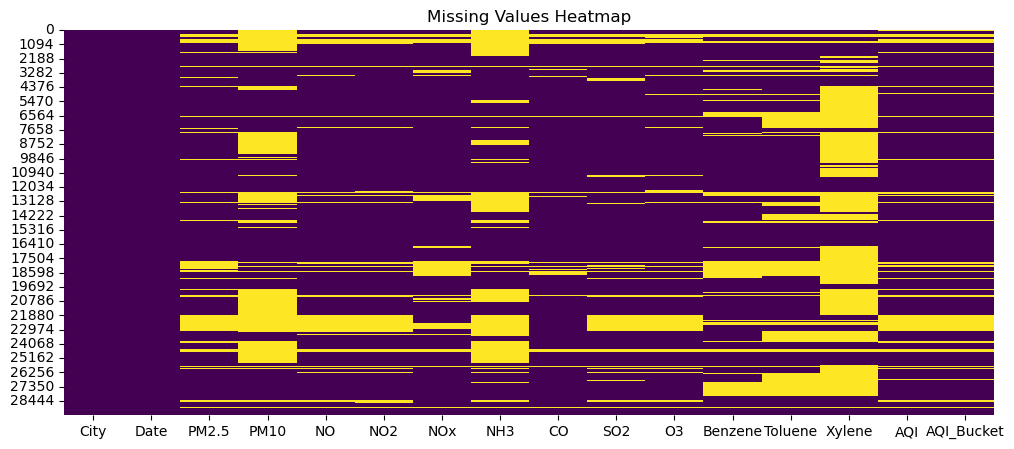

In [13]:
plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

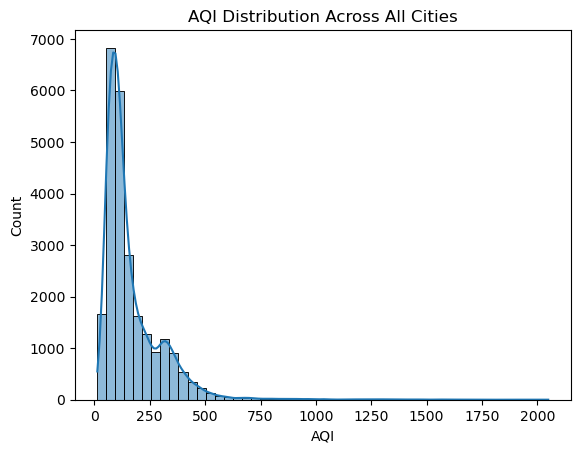

In [14]:
sns.histplot(df['AQI'].dropna(), bins=50, kde=True)
plt.title("AQI Distribution Across All Cities")
plt.show()

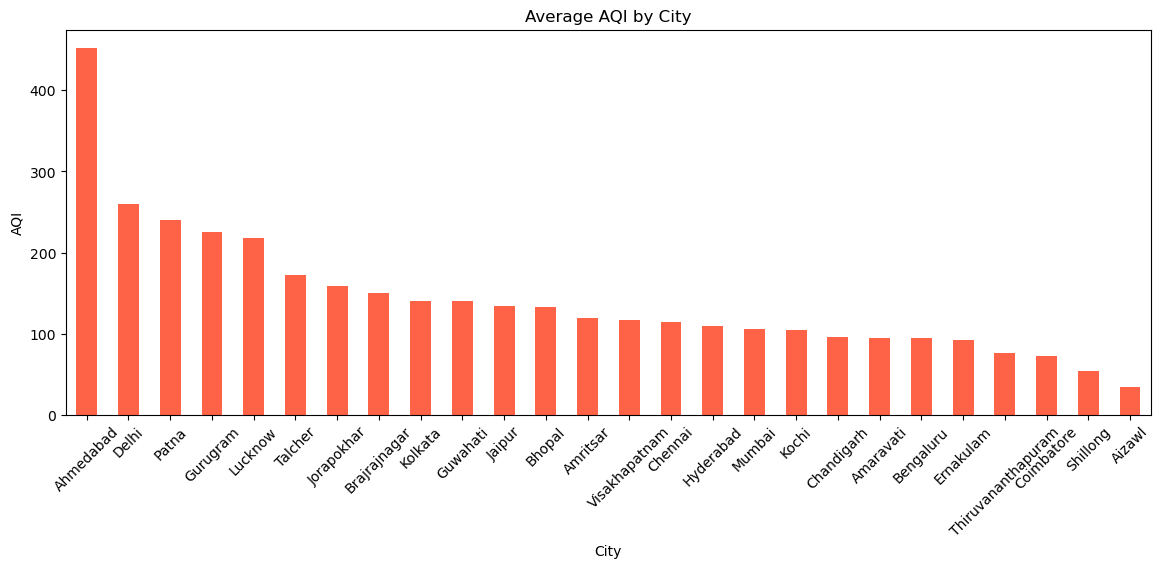

In [15]:
city_aqi = df.groupby('City')['AQI'].mean().sort_values(ascending=False)
city_aqi.plot(kind='bar', figsize=(14,5), color='tomato')
plt.title("Average AQI by City")
plt.ylabel("AQI")
plt.xticks(rotation=45)
plt.show()

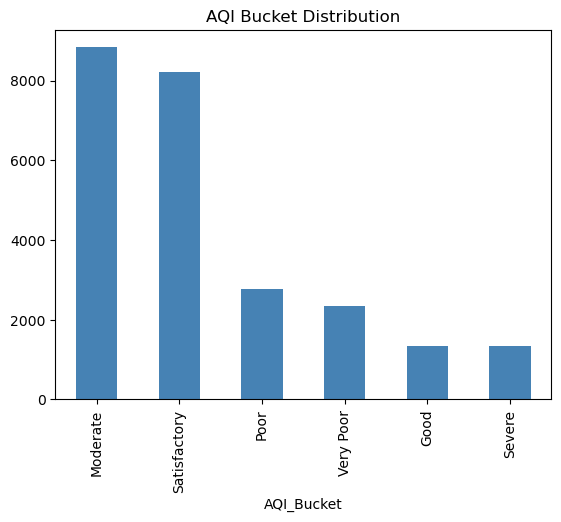

In [16]:
df['AQI_Bucket'].value_counts().plot(kind='bar', color='steelblue')
plt.title("AQI Bucket Distribution")
plt.show()

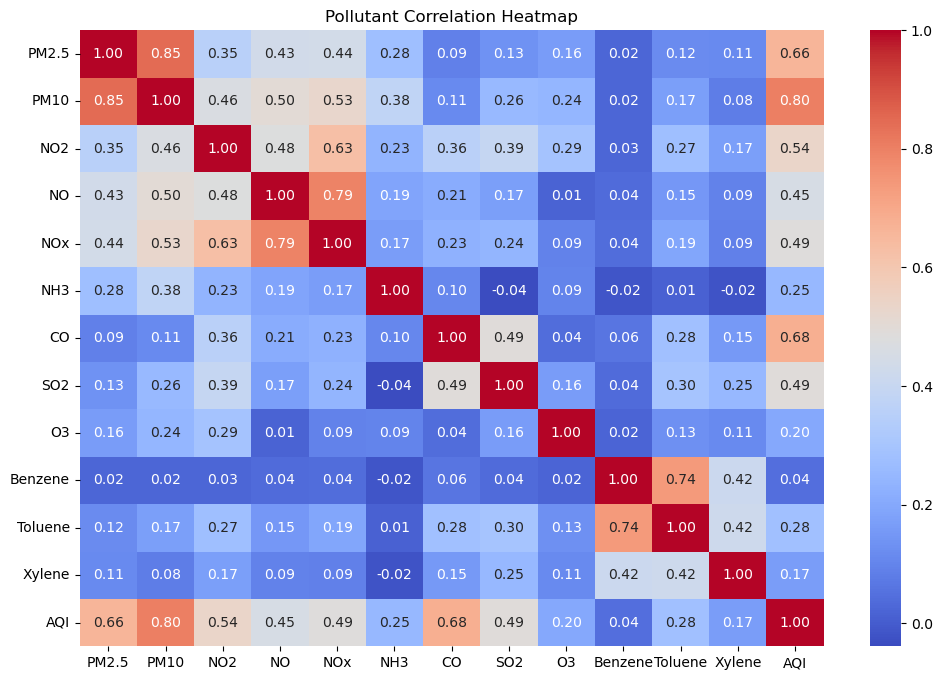

In [17]:
pollutants = ['PM2.5','PM10','NO2','NO','NOx','NH3','CO','SO2','O3','Benzene','Toluene','Xylene','AQI']
plt.figure(figsize=(12,8))
sns.heatmap(df[pollutants].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Pollutant Correlation Heatmap")
plt.show()

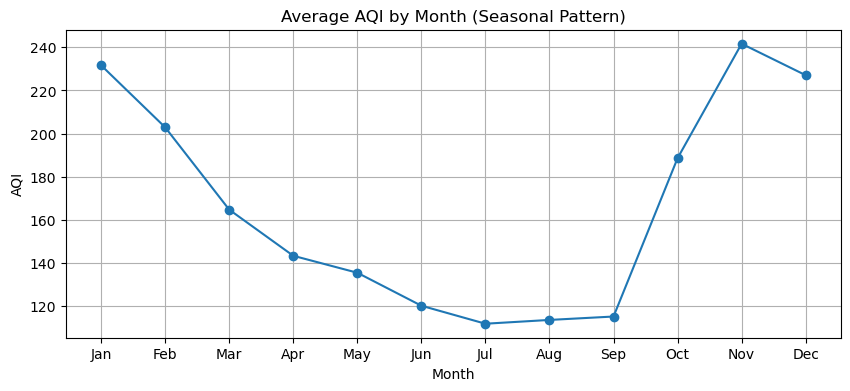

In [18]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
monthly_aqi = df.groupby('Month')['AQI'].mean()
monthly_aqi.plot(marker='o', figsize=(10,4))
plt.title("Average AQI by Month (Seasonal Pattern)")
plt.xlabel("Month")
plt.ylabel("AQI")
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True)
plt.show()

# Data Preprocessing & Feature Engineering

In [19]:
df = df.dropna(subset=['AQI', 'AQI_Bucket'])
print(df.shape)

(24850, 17)


In [20]:
pollutant_cols = ['PM2.5','PM10','NO2','NO','NOx','NH3','CO','SO2','O3','Benzene','Toluene','Xylene']

for col in pollutant_cols:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum() 

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
Month         0
dtype: int64

In [21]:
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Season mapping
def get_season(month):
    if month in [12, 1, 2]: return 0   # Winter
    elif month in [3, 4, 5]: return 1  # Summer
    elif month in [6, 7, 8, 9]: return 2  # Monsoon
    else: return 3                        # Post-monsoon

df['Season'] = df['Month'].apply(get_season)

In [22]:
le = LabelEncoder()
df['City_Encoded'] = le.fit_transform(df['City'])

In [23]:
df = df.sort_values(['City', 'Date'])  # sort first!

df['PM25_7day_avg'] = df.groupby('City')['PM2.5'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)
df['PM10_7day_avg'] = df.groupby('City')['PM10'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)

In [24]:
bucket_mapping = {
    'Good': 0,
    'Satisfactory': 1,
    'Moderate': 2,
    'Poor': 3,
    'Very Poor': 4,
    'Severe': 5
}
df['AQI_Bucket_Encoded'] = df['AQI_Bucket'].map(bucket_mapping)
df.dropna(subset=['AQI_Bucket_Encoded'], inplace=True)

In [25]:
feature_cols = ['PM2.5','PM10','NO2','NO','NOx','NH3','CO','SO2','O3',
                'Benzene','Toluene','Xylene','City_Encoded',
                'Month','Year','Season','PM25_7day_avg','PM10_7day_avg']

X = df[feature_cols]
y_reg = df['AQI']                    # regression target
y_clf = df['AQI_Bucket_Encoded']     # classification target

print(X.shape)

(24850, 18)


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)
_, _, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Regression Models (Predict AQI Value)

In [27]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

models_reg = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

reg_results = {}

for name, model in models_reg.items():
    model.fit(X_train_scaled, y_train_reg)
    preds = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test_reg, preds))
    r2 = r2_score(y_test_reg, preds)
    reg_results[name] = {'RMSE': round(rmse,2), 'R²': round(r2,4)}
    print(f"{name} → RMSE: {rmse:.2f}, R²: {r2:.4f}")

pd.DataFrame(reg_results).T

Linear Regression → RMSE: 56.82, R²: 0.8237
Ridge Regression → RMSE: 56.82, R²: 0.8237
Random Forest → RMSE: 39.48, R²: 0.9149


,RMSE,R²
Linear Regression,56.82,0.8237
Ridge Regression,56.82,0.8237
Random Forest,39.48,0.9149


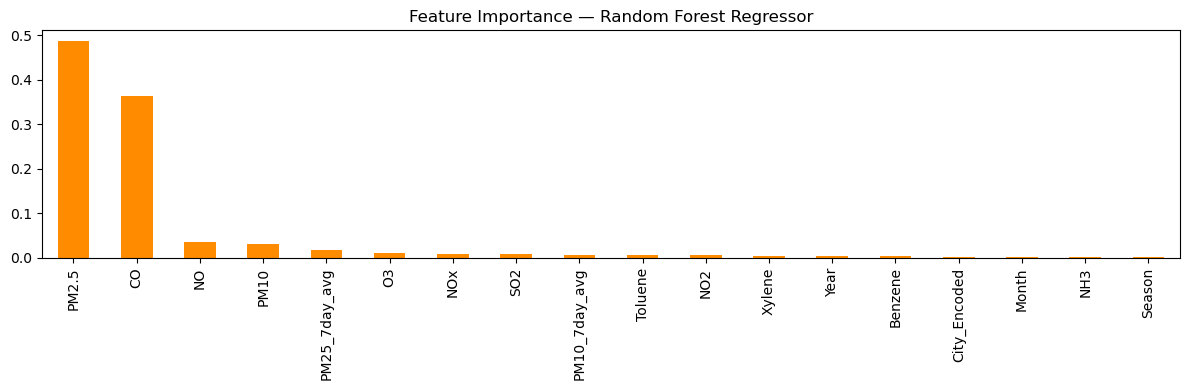

In [28]:
importances = models_reg['Random Forest'].feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(12,4), color='darkorange')
plt.title("Feature Importance — Random Forest Regressor")
plt.tight_layout()
plt.show()

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

models_clf = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest Classifier': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

for name, model in models_clf.items():
    model.fit(X_train_scaled, y_train_clf)
    preds = model.predict(X_test_scaled)
    f1 = f1_score(y_test_clf, preds, average='weighted')
    print(f"\n{name} — Weighted F1: {f1:.4f}")
    print(classification_report(y_test_clf, preds,
          target_names=['Good','Satisfactory','Moderate','Poor','Very Poor','Severe']))


Logistic Regression — Weighted F1: 0.7507
              precision    recall  f1-score   support

        Good       0.75      0.38      0.50       282
Satisfactory       0.77      0.83      0.80      1655
    Moderate       0.76      0.82      0.79      1745
        Poor       0.64      0.55      0.59       555
   Very Poor       0.75      0.73      0.74       462
      Severe       0.85      0.73      0.79       271

    accuracy                           0.76      4970
   macro avg       0.75      0.67      0.70      4970
weighted avg       0.75      0.76      0.75      4970


Random Forest Classifier — Weighted F1: 0.8170
              precision    recall  f1-score   support

        Good       0.86      0.63      0.73       282
Satisfactory       0.85      0.87      0.86      1655
    Moderate       0.82      0.87      0.84      1745
        Poor       0.71      0.67      0.69       555
   Very Poor       0.77      0.78      0.78       462
      Severe       0.88      0.76      0.

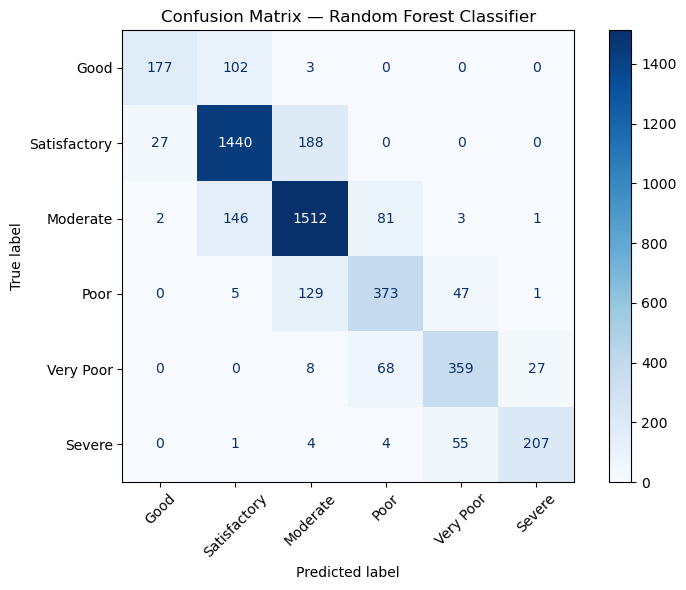

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

rf_clf = models_clf['Random Forest Classifier']
rf_clf_preds = rf_clf.predict(X_test_scaled)

cm = confusion_matrix(y_test_clf, rf_clf_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
       display_labels=['Good','Satisfactory','Moderate','Poor','Very Poor','Severe'])

fig, ax = plt.subplots(figsize=(8,6))   # ← size set here instead
disp.plot(xticks_rotation=45, cmap='Blues', ax=ax)  # ← pass ax in
plt.title("Confusion Matrix — Random Forest Classifier")
plt.tight_layout()
plt.show()

In [32]:
import os

os.chdir(r'C:\samruddhi\placements\internships\aqi_forecaster')
print(os.getcwd())


C:\samruddhi\placements\internships\aqi_forecaster


In [33]:
import joblib

joblib.dump(models_reg['Random Forest'], 'models/rf_regressor.pkl')
joblib.dump(models_clf['Random Forest Classifier'], 'models/rf_classifier.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le, 'models/label_encoder.pkl')

print("Models saved!")

Models saved!


In [34]:
print("=== REGRESSION RESULTS ===")
print(pd.DataFrame(reg_results).T.to_string())

print("\n=== CLASSIFICATION RESULTS ===")
for name, model in models_clf.items():
    preds = model.predict(X_test_scaled)
    f1 = f1_score(y_test_clf, preds, average='weighted')
    print(f"{name}: Weighted F1 = {f1:.4f}")

=== REGRESSION RESULTS ===
                    RMSE      R²
Linear Regression  56.82  0.8237
Ridge Regression   56.82  0.8237
Random Forest      39.48  0.9149

=== CLASSIFICATION RESULTS ===
Logistic Regression: Weighted F1 = 0.7507
Random Forest Classifier: Weighted F1 = 0.8170
